# DSAI 4103 — Business Analytics Project
## Notebook 03: AutoML Model Training
**Input:**  `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  
**Output:** `models/readmission_model.pkl`, `models/score.py`  
**Objective:** Train a readmission classifier using FLAML AutoML + evaluate with full metrics.

---
## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/Course_Project/'

Mounted at /content/drive


In [2]:
!pip install flaml[automl] lightgbm xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 8.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from flaml import AutoML
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

os.makedirs(BASE + 'models', exist_ok=True)
os.makedirs(BASE + 'outputs/figures', exist_ok=True)

print('All libraries loaded.')

All libraries loaded.


---
## 1. Load Train / Test Data

In [4]:
X_train = pd.read_csv(BASE + 'data/processed/X_train.csv')
X_test  = pd.read_csv(BASE + 'data/processed/X_test.csv')
y_train = pd.read_csv(BASE + 'data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv(BASE + 'data/processed/y_test.csv').squeeze()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.value_counts().to_dict()}')
print(f'y_test  : {y_test.value_counts().to_dict()}')

feature_names = X_train.columns.tolist()
print(f'\nFeatures: {len(feature_names)}')

X_train : (55978, 53)
X_test  : (13995, 53)
y_train : {0: 50956, 1: 5022}
y_test  : {0: 12740, 1: 1255}

Features: 53


---
## 2. Train with FLAML AutoML

FLAML automatically searches over LightGBM, XGBoost, Random Forest, and Extra Trees,
selecting the best model and hyperparameters within the time budget.

In [5]:
automl = AutoML()

automl_settings = {
    'task'           : 'classification',
    'metric'         : 'roc_auc',
    'time_budget'    : 1200,          # 20 minutes
    'estimator_list' : ['lgbm', 'xgboost', 'rf', 'extra_tree'],
    'eval_method'    : 'cv',          # cross-validation
    'n_splits'       : 5,             # 5-fold CV
    'seed'           : 42,
    'verbose'        : 1,
}

print('Starting FLAML AutoML training...')
print(f'Time budget: 20 minutes | Metric: ROC-AUC | Models: LightGBM, XGBoost, RF, ExtraTrees')
print('-' * 60)

automl.fit(X_train, y_train, **automl_settings)

print('-' * 60)
print(f'\nBest model      : {automl.best_estimator}')
print(f'Best CV AUC     : {1 - automl.best_loss:.4f}')
print(f'Best config     : {automl.best_config}')

Starting FLAML AutoML training...
Time budget: 20 minutes | Metric: ROC-AUC | Models: LightGBM, XGBoost, RF, ExtraTrees
------------------------------------------------------------
------------------------------------------------------------

Best model      : xgboost
Best CV AUC     : 0.6625
Best config     : {'n_estimators': 192, 'max_leaves': 104, 'min_child_weight': np.float64(1.6377744786636965), 'learning_rate': np.float64(0.019112556880085462), 'subsample': 1.0, 'colsample_bylevel': 1.0, 'colsample_bytree': np.float64(0.21468803138041198), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(3.8287871408623264)}


---
## 3. Evaluate on Test Set

In [6]:
# Predictions
y_pred      = automl.predict(X_test)
y_prob      = automl.predict_proba(X_test)[:, 1]

# Core metrics
test_auc    = roc_auc_score(y_test, y_prob)
avg_prec    = average_precision_score(y_test, y_prob)

print('=' * 55)
print('          TEST SET PERFORMANCE')
print('=' * 55)
print(f'ROC-AUC Score        : {test_auc:.4f}')
print(f'Average Precision    : {avg_prec:.4f}')
print('=' * 55)
print('\nClassification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['Not Readmitted', 'Readmitted <30d']
))

          TEST SET PERFORMANCE
ROC-AUC Score        : 0.6586
Average Precision    : 0.1802

Classification Report:
                 precision    recall  f1-score   support

 Not Readmitted       0.91      1.00      0.95     12740
Readmitted <30d       0.00      0.00      0.00      1255

       accuracy                           0.91     13995
      macro avg       0.46      0.50      0.48     13995
   weighted avg       0.83      0.91      0.87     13995



---
## 4. Evaluation Plots

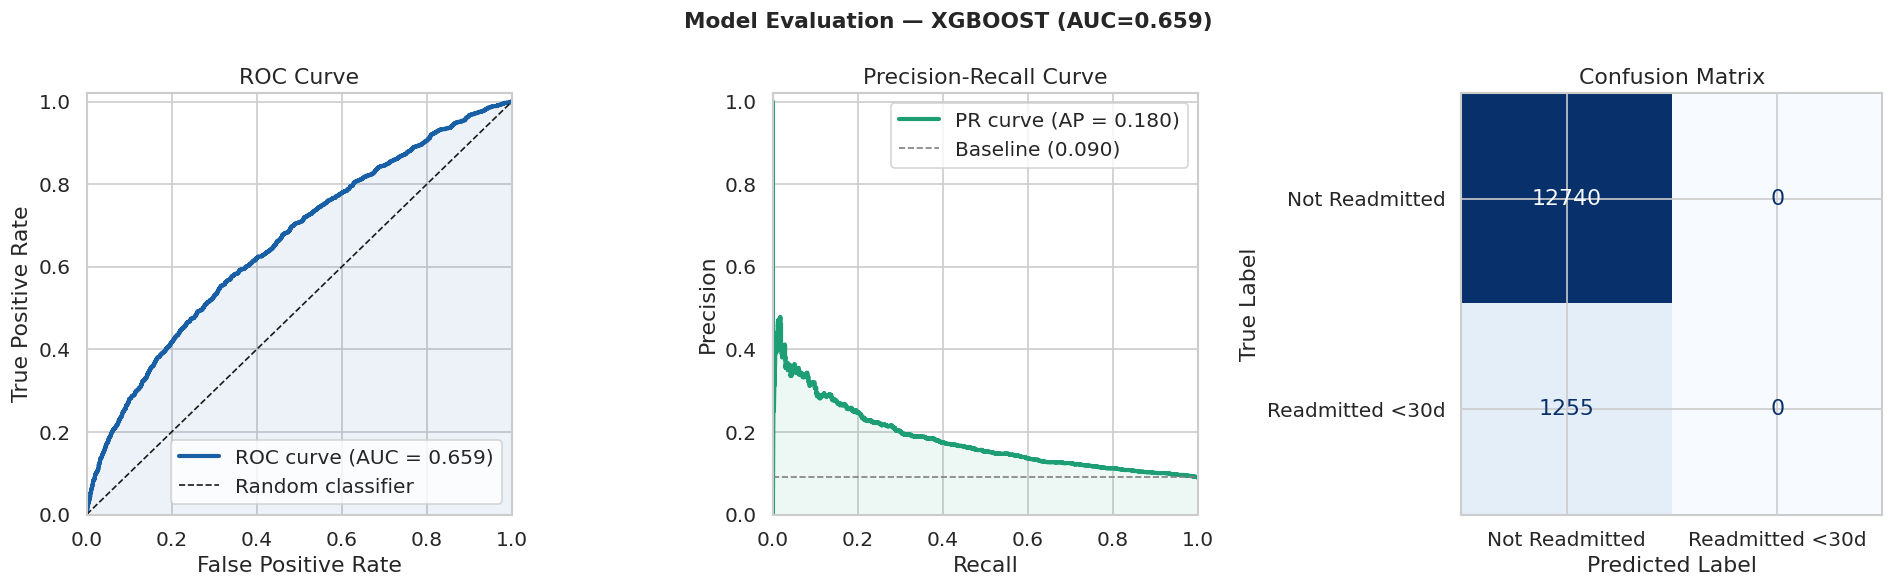

Saved: outputs/figures/11_model_evaluation.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 4.1 ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#185FA5', linewidth=2.5,
             label=f'ROC curve (AUC = {test_auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#185FA5')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0,1])
axes[0].set_ylim([0,1.02])

# 4.2 Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, color='#1D9E75', linewidth=2.5,
             label=f'PR curve (AP = {avg_prec:.3f})')
baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1,
                label=f'Baseline ({baseline:.3f})')
axes[1].fill_between(rec, prec, alpha=0.08, color='#1D9E75')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')
axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1.02])

# 4.3 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Readmitted', 'Readmitted <30d']
)
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.suptitle(f'Model Evaluation — {automl.best_estimator.upper()} (AUC={test_auc:.3f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/11_model_evaluation.png')
plt.show()
print('Saved: outputs/figures/11_model_evaluation.png')

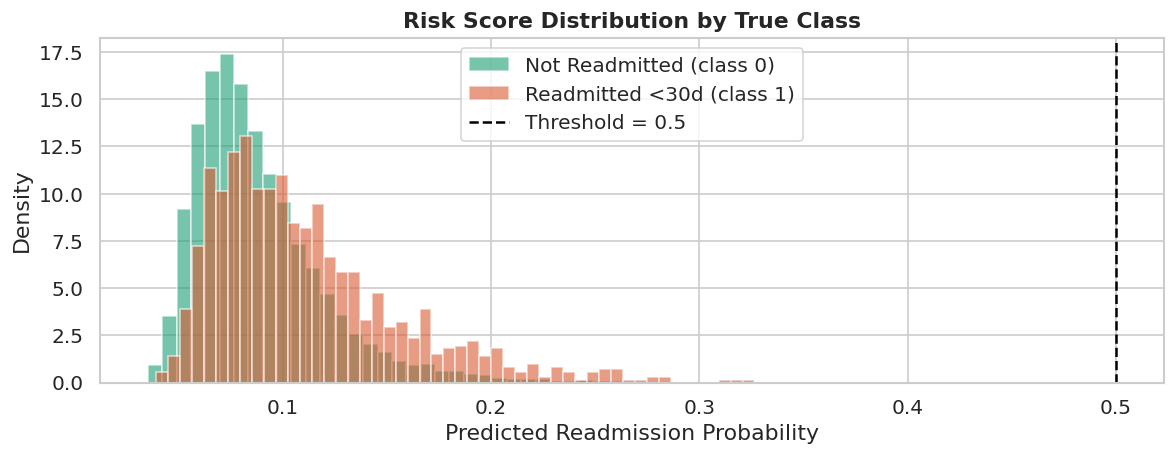

Saved: outputs/figures/12_risk_score_dist.png


In [8]:
# 4.4 Risk Score Distribution
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(y_prob[y_test == 0], bins=50, alpha=0.6,
        color='#1D9E75', label='Not Readmitted (class 0)', density=True)
ax.hist(y_prob[y_test == 1], bins=50, alpha=0.6,
        color='#D85A30', label='Readmitted <30d (class 1)', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
ax.set_xlabel('Predicted Readmission Probability')
ax.set_ylabel('Density')
ax.set_title('Risk Score Distribution by True Class', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(BASE + 'outputs/figures/12_risk_score_dist.png')
plt.show()
print('Saved: outputs/figures/12_risk_score_dist.png')

---
## 5. Feature Importance (Built-in)

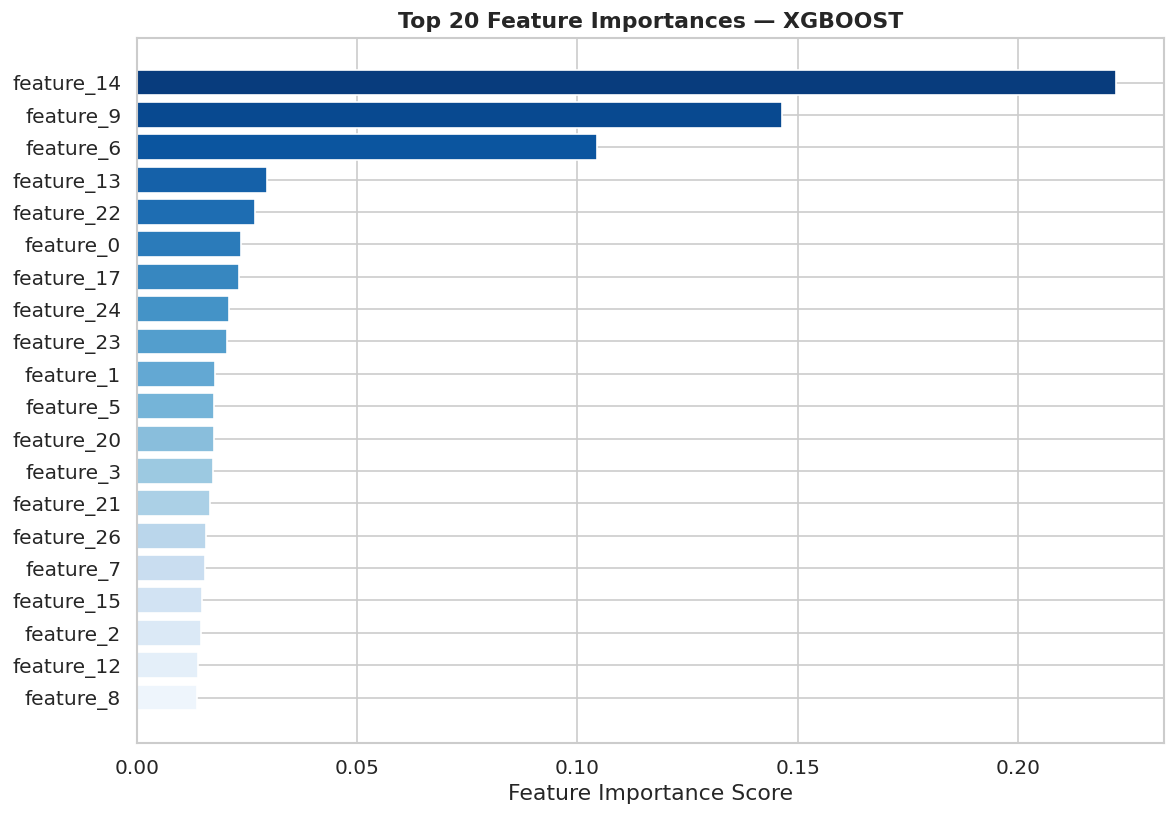

Saved: outputs/figures/13_feature_importance.png
Saved: data/processed/pbi_feature_importance.csv

Importance array length : 50
Feature names length    : 53


In [10]:
try:
    importances = automl.model.estimator.feature_importances_

    # Use the actual feature names from the fitted model if available
    if hasattr(automl.model.estimator, 'feature_name_'):
        fitted_features = automl.model.estimator.feature_name_()
    elif len(importances) != len(feature_names):
        # Fallback: create generic names matching the importance array length
        fitted_features = [f'feature_{i}' for i in range(len(importances))]
    else:
        fitted_features = feature_names

    feat_imp = pd.DataFrame({
        'feature'   : fitted_features,
        'importance': importances
    }).sort_values('importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    palette = sns.color_palette('Blues_r', len(feat_imp))
    ax.barh(feat_imp['feature'], feat_imp['importance'],
            color=palette, edgecolor='white')
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance Score')
    ax.set_title(f'Top 20 Feature Importances — {automl.best_estimator.upper()}',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(BASE + 'outputs/figures/13_feature_importance.png')
    plt.show()

    feat_imp.to_csv(BASE + 'data/processed/pbi_feature_importance.csv', index=False)
    print('Saved: outputs/figures/13_feature_importance.png')
    print('Saved: data/processed/pbi_feature_importance.csv')
    print(f'\nImportance array length : {len(importances)}')
    print(f'Feature names length    : {len(feature_names)}')

except AttributeError:
    print('Feature importance not available — will use SHAP in notebook 04.')

---
## 6. Save Model & Scoring Script

In [20]:
# Save trained AutoML model
with open(BASE + 'models/readmission_model.pkl', 'wb') as f:
    pickle.dump(automl, f)

# Save feature names
with open(BASE + 'models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# Save test predictions for bias analysis notebook
results_df = X_test.copy()
results_df['y_true'] = y_test.values
results_df['y_pred'] = y_pred
results_df['y_prob'] = y_prob
results_df.to_csv(BASE + 'data/processed/test_predictions.csv', index=False)

print('Model saved    : models/readmission_model.pkl')
print('Features saved : models/feature_names.pkl')
print('Predictions    : data/processed/test_predictions.csv')

Model saved    : models/readmission_model.pkl
Features saved : models/feature_names.pkl
Predictions    : data/processed/test_predictions.csv


In [21]:
# lower decision threshold to handle class imbalance
# Instead of default 0.5, use the class prevalence as threshold
threshold = y_train.mean()  # ~0.09
print(f'Using threshold: {threshold:.3f} instead of default 0.5')

y_pred_adj = (y_prob >= threshold).astype(int)

from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

print('\nAdjusted Threshold Metrics:')
print(f'  Precision (class1): {precision_score(y_test, y_pred_adj):.4f}')
print(f'  Recall    (class1): {recall_score(y_test, y_pred_adj):.4f}')
print(f'  F1        (class1): {f1_score(y_test, y_pred_adj):.4f}')
print(f'  ROC-AUC           : {roc_auc_score(y_test, y_prob):.4f}')

# Save adjusted predictions
results_df = X_test.copy()
results_df['y_true'] = y_test.values
results_df['y_pred'] = y_pred_adj
results_df['y_prob'] = y_prob
results_df.to_csv(BASE + 'data/processed/test_predictions.csv', index=False)
print('\nUpdated test_predictions.csv saved.')

Using threshold: 0.090 instead of default 0.5

Adjusted Threshold Metrics:
  Precision (class1): 0.1340
  Recall    (class1): 0.6096
  F1        (class1): 0.2197
  ROC-AUC           : 0.6586

Updated test_predictions.csv saved.


In [22]:
# Write scoring script to Google Drive
score_script = '''
# score.py — Deployment scoring script for Diabetes Readmission Model
# Usage: python score.py

import pickle
import pandas as pd
import numpy as np

MODEL_PATH   = 'models/readmission_model.pkl'
FEATURES_PATH = 'models/feature_names.pkl'


def init():
    """Load model and feature names into memory."""
    global model, feature_names
    with open(MODEL_PATH, 'rb') as f:
        model = pickle.load(f)
    with open(FEATURES_PATH, 'rb') as f:
        feature_names = pickle.load(f)
    print(f"Model loaded: {model.best_estimator}")
    print(f"Features    : {len(feature_names)}")


def run(raw_data: pd.DataFrame) -> dict:
    """
    Score new patient records.

    Parameters
    ----------
    raw_data : pd.DataFrame
        DataFrame with the same feature columns used during training.

    Returns
    -------
    dict with keys:
        predictions   — binary class (0 or 1)
        probabilities — readmission probability (0.0 – 1.0)
        risk_label    — human-readable risk tier
    """
    data = raw_data[feature_names].copy()

    predictions   = model.predict(data)
    probabilities = model.predict_proba(data)[:, 1]

    risk_labels = pd.cut(
        probabilities,
        bins=[0, 0.05, 0.15, 0.30, 1.0],
        labels=['Low', 'Medium', 'High', 'Very High']
    ).astype(str)

    return {
        'predictions'   : predictions.tolist(),
        'probabilities' : probabilities.round(4).tolist(),
        'risk_label'    : risk_labels.tolist()
    }


if __name__ == "__main__":
    init()

    # Test with a dummy sample
    sample = pd.DataFrame([{f: 0 for f in feature_names}])
    result = run(sample)

    print("\nSample prediction:")
    print(f"  Prediction   : {result['predictions'][0]}")
    print(f"  Probability  : {result['probabilities'][0]}")
    print(f"  Risk label   : {result['risk_label'][0]}")
    print("\nScoring script working correctly.")
'''

with open(BASE + 'models/score.py', 'w') as f:
    f.write(score_script)

print('Scoring script saved: models/score.py')

Scoring script saved: models/score.py


In [23]:
# Quick test of the scoring script inline
sample = pd.DataFrame([{f: 0 for f in feature_names}])

pred  = automl.predict(sample)
prob  = automl.predict_proba(sample)[:, 1]

risk = pd.cut(prob, bins=[0, 0.05, 0.15, 0.30, 1.0],
              labels=['Low', 'Medium', 'High', 'Very High'])

print('Scoring script test — dummy patient:')
print(f'  Prediction   : {pred[0]}')
print(f'  Probability  : {prob[0]:.4f}')
print(f'  Risk label   : {risk[0]}')
print('Scoring script working correctly.')

Scoring script test — dummy patient:
  Prediction   : 0
  Probability  : 0.0545
  Risk label   : Medium
Scoring script working correctly.


---
## 7. Model Training Summary

In [25]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

print('=' * 55)
print('         MODEL TRAINING SUMMARY')
print('=' * 55)
print(f'Best model          : {automl.best_estimator.upper()}')
print(f'CV ROC-AUC          : {1 - automl.best_loss:.4f}')
print('-' * 55)
print(f'Threshold used      : {threshold:.3f} (adjusted for imbalance)')
print('Test Set Metrics:')
print(f'  ROC-AUC           : {roc_auc_score(y_test, y_prob):.4f}')
print(f'  Average Precision : {average_precision_score(y_test, y_prob):.4f}')
print(f'  Accuracy          : {accuracy_score(y_test, y_pred_adj):.4f}')
print(f'  Precision (class1): {precision_score(y_test, y_pred_adj):.4f}')
print(f'  Recall    (class1): {recall_score(y_test, y_pred_adj):.4f}')
print(f'  F1        (class1): {f1_score(y_test, y_pred_adj):.4f}')
print('-' * 55)
print('Saved outputs:')
print('  models/readmission_model.pkl')
print('  models/feature_names.pkl')
print('  models/score.py')
print('  data/processed/test_predictions.csv')
print('  outputs/figures/11_model_evaluation.png')
print('  outputs/figures/12_risk_score_dist.png')
print('  outputs/figures/13_feature_importance.png')
print('=' * 55)
print('Next step → 04_explainability_bias.ipynb')

         MODEL TRAINING SUMMARY
Best model          : XGBOOST
CV ROC-AUC          : 0.6625
-------------------------------------------------------
Threshold used      : 0.090 (adjusted for imbalance)
Test Set Metrics:
  ROC-AUC           : 0.6586
  Average Precision : 0.1802
  Accuracy          : 0.6116
  Precision (class1): 0.1340
  Recall    (class1): 0.6096
  F1        (class1): 0.2197
-------------------------------------------------------
Saved outputs:
  models/readmission_model.pkl
  models/feature_names.pkl
  models/score.py
  data/processed/test_predictions.csv
  outputs/figures/11_model_evaluation.png
  outputs/figures/12_risk_score_dist.png
  outputs/figures/13_feature_importance.png
Next step → 04_explainability_bias.ipynb
